# Titanic Survival Prediction

In [1]:
import pandas as pd

df = pd.read_csv('/content/Titanic_Survival_Prediction_Dataset.csv')
display(df.head())

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,29.4,1,0,8.86,Q
1,2,0,3,female,36.1,1,4,12.37,Q
2,3,1,1,female,33.4,0,1,116.71,Q
3,4,0,2,male,42.2,0,3,27.47,S
4,5,0,2,female,38.0,4,0,14.10,C


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1000 non-null   int64  
 1   Survived     1000 non-null   int64  
 2   Pclass       1000 non-null   int64  
 3   Sex          1000 non-null   object 
 4   Age          1000 non-null   float64
 5   SibSp        1000 non-null   int64  
 6   Parch        1000 non-null   int64  
 7   Fare         1000 non-null   float64
 8   Embarked     1000 non-null   object 
dtypes: float64(2), int64(5), object(2)
memory usage: 70.4+ KB


In [3]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


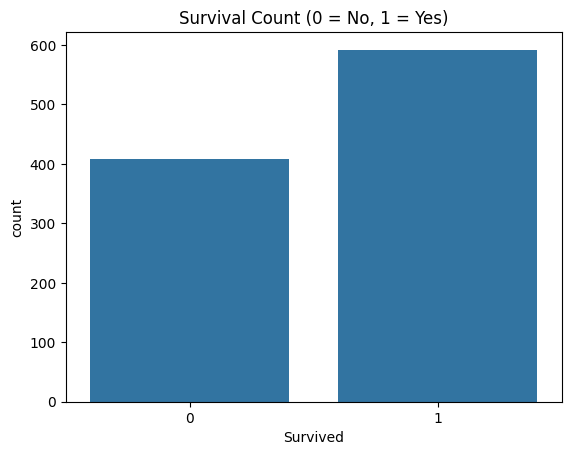

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Survived', data=df)
plt.title('Survival Count (0 = No, 1 = Yes)')
plt.show()

In [5]:
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)
display(df.head())

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,29.4,1,0,8.86,True,True,False
1,2,0,3,36.1,1,4,12.37,False,True,False
2,3,1,1,33.4,0,1,116.71,False,True,False
3,4,0,2,42.2,0,3,27.47,True,False,True
4,5,0,2,38.0,4,0,14.10,False,False,False


In [6]:
X = df.drop(['Survived', 'PassengerId'], axis=1)
y = df['Survived']

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (1000, 8)
Shape of y: (1000,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (800, 8)
Shape of X_test: (200, 8)
Shape of y_train: (800,)
Shape of y_test: (200,)


In [8]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=42, solver='liblinear')
log_reg.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [9]:
from sklearn.metrics import accuracy_score

y_pred_lr = log_reg.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")

Logistic Regression Accuracy: 0.8200


In [10]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully.")

Decision Tree Classifier trained successfully.


In [11]:
y_pred_dtc = dtc.predict(X_test)
accuracy_dtc = accuracy_score(y_test, y_pred_dtc)

print(f"Decision Tree Classifier Accuracy: {accuracy_dtc:.4f}")

Decision Tree Classifier Accuracy: 0.6850
